# Tarea 3: Clasificación de galaxias con una CNN

## Por Úrsula Sáez y Martín Raffo

## Profesora Pía Amigo

## Curso de Big Data, Agosto 2026.

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Consideraciones
- La tarea se hace en grupos máximos de **2 personas**
- Debe realizar todas las actividades descritas más abajo y responder y comentar lo que se pide.
- **La tarea se entrega el día viernes 07/08, 23:59 horas.**

--

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

In [ ]:
# librerías
import h5py
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

## Configuración de sesión de colab
Debemos trabajar en Google Colab, que tiene la ventaja de tener tensorflow y Keras ya instalado y además levanta un servidor de GPU suficiente para el propósito de esta tarea.  
Para activarlo, debe ir a `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar que  `device_type=GPU`

In [ ]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#monte su cuenta de google drive para trabajar en una carpeta ahí. Le pedirá autentificación
#from google.colab import drive
#drive.mount('/content/drive')

Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [ ]:
#path = "/content/drive/MyDrive/AST332_ML/2026/Binary_2_5_dataset.h5" #cambie este path al correspondiente suyo, en su carpeta drive
path = "Binary_2_5_dataset.h5"

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(images.shape)
print(labels.shape)

classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(c, n)

(4688, 256, 256, 3)
(4688,)
0 2645
1 2043


# **1. Exploración de datos**

## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [ ]:
X = images
y = labels.astype("int32")

Para visualizar las imágenes

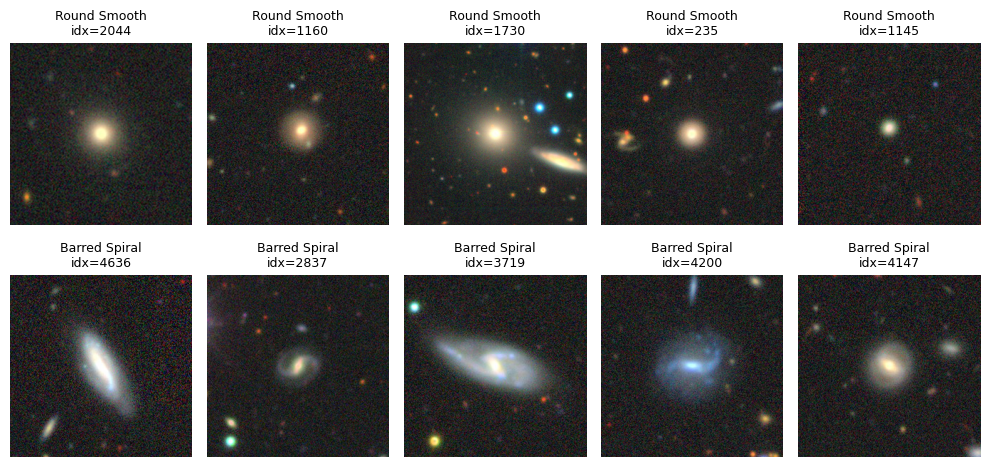

In [ ]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

**¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?**

*Respuesta:* Principalmente se observan diferencias en su morfología. En las galaxias Round Smooth se puede apreciar que la luz es emitida de forma concentrada y puntual desde su núcleo como si fuera una estrella, y como su nombre dice es suave ya que no se aprecian mayores estructuras. Por otro lado las galaxias Barred Spiral, se ve de forma más clara estructuras del tipo barra y brazos espirales.

**¿Qué características espera que pueda aprender la red?**

*Respuesta:* Podría aprender de features morfológicas tales como Elipticidad, Asimetría, Concentración, entre otras, para poder realizar una clasificación de galaxias.

In [ ]:
clase, total = np.unique(y, return_counts=True)
print(dict(zip(clase, total)))

{np.int32(0): np.int64(2645), np.int32(1): np.int64(2043)}


In [ ]:
razon = total[1] / total[0]
print(f"Razón: {razon:.2f}")

Razón: 0.77


**¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?**

*Respuesta:* La proporción es de 0.77, existiendo una mayor cantidad de galaxias Round Smooth con un total de 2645 imagenes frente a las 2043 galaxias Barred Spiral. Un modelo que prediga solo la clase más frecuente obtendría un accuracy del $77\%$.

# **2. Preparación de datos**

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [ ]:
# Se separa un test del 30%,
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=10) # stratify para mantener separación de clases

# De los datos restantes se separa en train y test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, stratify=y_temp, random_state=10)

print(X_train.shape, X_val.shape, X_test.shape)
print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

(2296, 256, 256, 3) (985, 256, 256, 3) (1407, 256, 256, 3)
Balance train: 0.43597560975609756 | val: 0.4355329949238579 | test: 0.43567874911158494


In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Train: (2296, 256, 256, 3) (2296,)
Val: (985, 256, 256, 3) (985,)
Test: (1407, 256, 256, 3) (1407,)
Train classes: (array([0, 1], dtype=int32), array([1295, 1001]))
Val classes: (array([0, 1], dtype=int32), array([556, 429]))
Test classes: (array([0, 1], dtype=int32), array([794, 613]))


**Justifique brevemente por qué es importante tener estos tres conjuntos**

*Respuesta:* Con entrenamiento, el modelo aprende las diferencias morfológicas que pueden ser continuamente evaluadas con el conjunto de validación. Es necesario separar otro conjunto de test que no esté contaminado y que no haya interactuado con el modelo. De esta forma buscamos lograr que el modelo aprenda de los datos, en este caso a identificar las galaxias, en vez de memorizar las imágenes.

# 3. Arquitectura de la red

## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple usando
Keras. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

**1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?**

  *Respuesta:* Se utilizaron 11 capas, las cuales se muestran en la tabla de resumen de la arquitectura. Hay capas que si debían ser consideradas como las de entrada, normalización y salida, se trabajó principalmente con modificar el número de bloques convolucionales para mejorar el desempeño del modelo. En un principio se intentó con dos bloques y finalmente se optó por tres bloques por tener resultados más satisfactorios.


**2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.**

   *Respuesta:* No se usaron el mismo número de filtros, se fueron aumentando en cada capa. En los bloques 1, 2 y 3 se utilizaron 32, 64 y 128 filtros respectivamente; esto con el objetivo de encontrar estructuras más complejas en las imágenes a medida que el modelo aprende.

**3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?**

   *Respuesta:* Se utilizó la función "ReLu". Además de ser una función estándar al momento de trabajar con redes convolucionales es útil por su simpleza y rápidez en los cálculos del entrenamiento, a diferencia de funciones como "Sigmoid" y "Tanh". Dado los buenos resultados obtenidos, se optó por mantener la función de activación.

**4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?**

   *Respuesta:* Se usó `MaxPooling2D`. Este método reduce el costo computacional al disminuir la cantidad de parámetros que la red debe calcular, resumiendo la información espacial de una región de 2x2 píxeles para este caso, donde toman relevancia los píxeles más brillantes.

**5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?**

   *Respuesta:* Se usó la función `GlobalAveragePooling2D` debido a que tiene menor costo computacional, calcula el promedio de cada mapa y lo asigna a un solo valor. Esto reduce la cantidad de parámetros previniendo así el sobreajuste.
   Por otro lado `Flatten` directamente aplana los parámetros en un vector 1D gigantesco, exponiendo al modelo a la tendencia de sobreajuste.

**6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?**

   *Respuesta:* Es necesario aplicar una de estas técnicas para poder evitar que el modelo memorice el ruido de las imágenes y que pueda generalizar sin entrar en detalles. A pesar de que el modelo estaba teniendo buenos resultados decidimos incluir `EarlyStopping` para asegurarnos que el modelo se detenga antes de empezar a memorizar.

**7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?**

   *Respuesta:* Debe tener la función "Sigmoid", ya que esta solo puede dar valores entre 0 y 1. Esto es justamente lo que se necesita para clasificación binaria: mientras más cerca del 0, será Round Smooth, mientras más cerca del 1, será Barred Spiral.

**8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.**

   *Respuesta:* La función de pérdida a utilizar corresponde a "binary_crossentropy". Esta función está específicamente diseñada para problemas de calificación binaria, como indica su nombre. Compara distribuciones de probabilidad según las predicciones y penaliza errores eficazmente a través de su fórmula de entropía.

## Plantilla de la red
Complete de acuerdo a su elección de la arquitectura. Debe reemplazar los __ con los valores correspondientes

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible


 --
 ### [Bloque convolucional](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

```python
layers.Conv2D(____, kernel_size=____, activation=____)
```

- **Primer `____`**: cantidad de filtros de la capa.
- **`kernel_size`**: tamaño de la ventana convolucional.
- **`activation`**: función de activación de la capa.

### [Pooling final](https://keras.io/api/layers/pooling_layers/)

```python
layers.________________()
```

Capa de pooling que reduce el mapa de características a un vector, antes de pasar a las capas densas.

### Capa densa intermedia

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas** de la capa.
- **`activation`**: función de activación.

### Capa de salida

```python
layers.Dense(____, activation=____)
```

- **Número de neuronas**: debe ser consistente con el tipo de problema (clasificación binaria) y con el `loss` ya definido en el `compile`.
- **`activation`**: debe ser coherente con esa misma decisión.

In [ ]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)), # Capa de entrada, cantidad de neuronas igual a la cantidad de features
    layers.Rescaling(1./255), # Capa de normalización, funciona como escalado


    # Bloque convolucional 1
    layers.Conv2D(32, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloque convolucional 2
    layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)), # pool_size para reducir el tamaño espacial a una ventana de 2x2 pixeles, reduciendo a la mitad alto y ancho de la imagen

    # Bloque convolucional 3
    layers.Conv2D(128, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Parte final de clasificación, capa de pooling
    layers.GlobalAveragePooling2D(), # Al guardar en una dimension flatten en una dimension, muchos datos --> sobreajuste

    layers.Dense(32, activation="relu"), # Capa densa fully connected

    # Capa de salida
    layers.Dense(1, activation="sigmoid") # Problema de clasificación binaria porque tenemos dos tipos de clasificaciones
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model.summary() # Resumen de la arquitectura de la red


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,409 (380.50 KB)

 Trainable params: 97,409 (380.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#regularizacion early stopping de la red https://keras.io/api/callbacks/early_stopping/
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True)

# para correr la red
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, #puede modificar este valor
    batch_size=32,#puede modificar este valor
    callbacks=[early_stop])

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.5597 - loss: 0.6857 - val_accuracy: 0.5645 - val_loss: 0.6747
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.6829 - loss: 0.6037 - val_accuracy: 0.7482 - val_loss: 0.5064
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.7591 - loss: 0.5094 - val_accuracy: 0.7624 - val_loss: 0.4920
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7796 - loss: 0.4762 - val_accuracy: 0.7716 - val_loss: 0.5061
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.7875 - loss: 0.4579 - val_accuracy: 0.7868 - val_loss: 0.4732
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.7905 - loss: 0.4451 - val_accuracy: 0.7898 - val_loss: 0.4755
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8027 - loss: 0.4367 - val_accuracy: 0.7898 - val_loss: 0.4663
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.8010 - loss: 0.4359 - val_accuracy: 0.7726 -

# 4. Entrenamiento

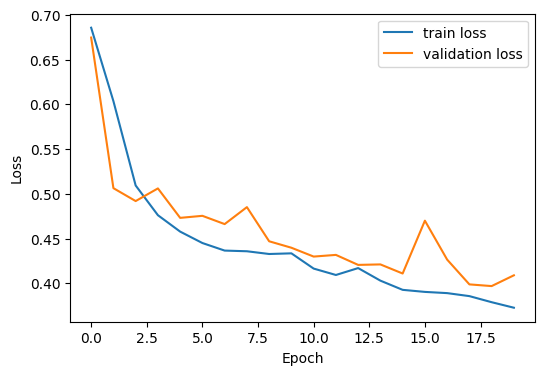

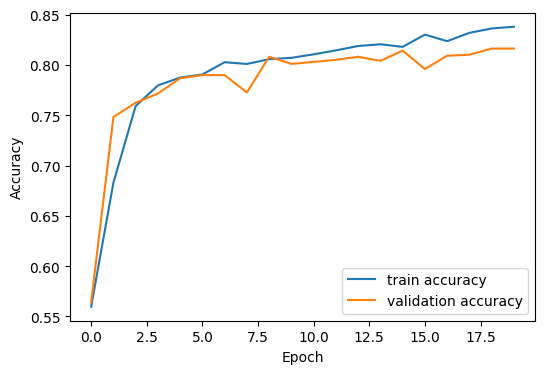

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable**

*Respuesta:* Observando los gráficos de pérdida y accuracy vemos que podría existir un overfitting leve, debido a que las curvas de train y test no son estables una vez encontrado el punto mínimo, mostrando un pequeño empeoramiento del modelo.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8273 - loss: 0.3749
Test loss: 0.3749
Test accuracy: 0.8273


# 5. Evaluación del modelo

#### Genere la matriz de confusión y las métricas

In [ ]:
y_pred_proba = model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Round Smooth", "Barred Spiral"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print()

               precision    recall  f1-score   support

 Round Smooth       0.82      0.88      0.85       794
Barred Spiral       0.83      0.75      0.79       613

     accuracy                           0.83      1407
    macro avg       0.83      0.82      0.82      1407
 weighted avg       0.83      0.83      0.83      1407

AUC-ROC: 0.9137
Matriz de confusión:
[[702  92]
 [151 462]]



In [ ]:
# 702 VN, 462 VP, 92 FP, 151 FN

**¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique**

*Respuesta:* El accuracy no es suficiente, ya que solo evalua el rendimiento global y no el caso de cada tipo de galaxia en particular. Analicemos:
- Con un accuracy de 0.83 significa que el 83% de las veces las predicciones son correctas, en general bastante confiable.
- Los valores de 0.88 para smooth y 0.75 para spiral significa que el modelo detecta casi la totalidad de las galaxias reales según cada tipo.
- Valores de 0.85 para smooth y 0.79 para spiral muestran un rendimiento equilibrado para ambas clases, manteniendo los valores hartos cercanos al 80%.
- Con el AUC-ROC se evidencia la capacidad del modelo: casi llega al 1 con un 0.9137, lo que significa que el modelo es muy bueno discriminando entre clases.

# 6. Análisis de errores

#### Revise algunos ejemplos de galaxias mal clasificadas

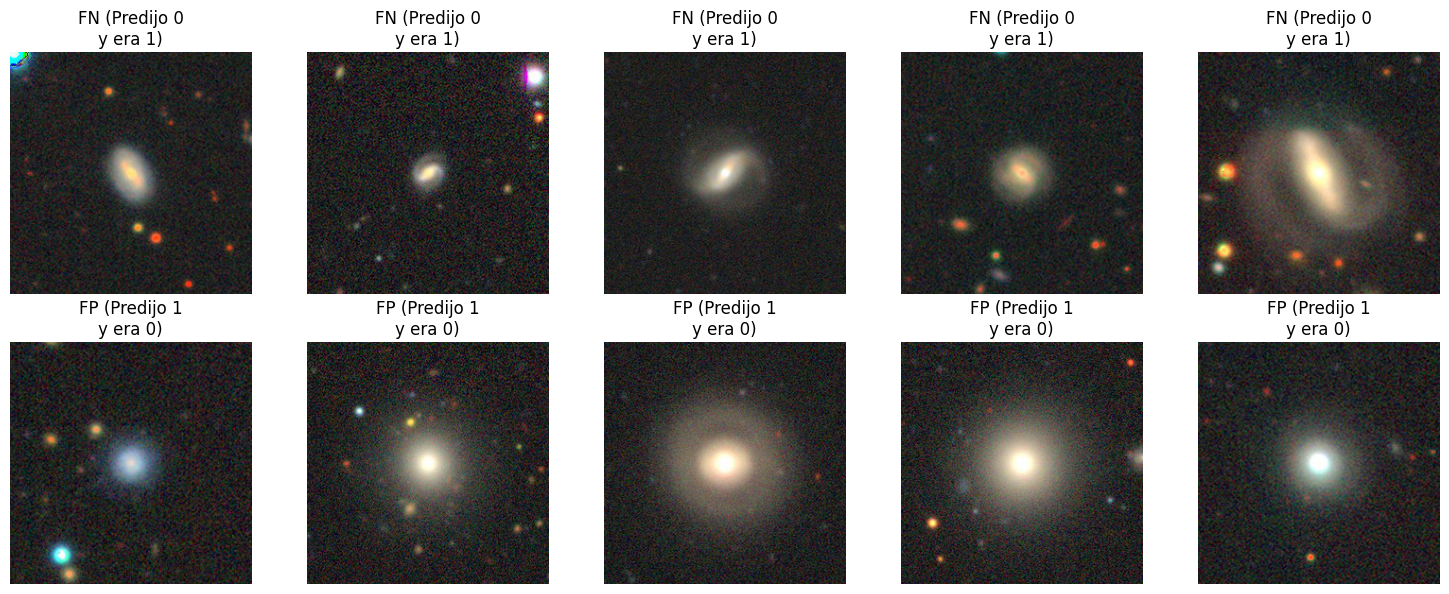

In [ ]:
imagenes_fn = X_test[(y_test == 1) & (y_pred == 0)] # Barred Spiral predichas como Round Smooth
imagenes_fp = X_test[(y_test == 0) & (y_pred == 1)] # Round Smooth predichas como Barred Spiral

plt.figure(figsize=(15, 6))

# Se grafican 5 falsos negativos
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(imagenes_fn[i])
    plt.title("FN (Predijo 0\ny era 1)")
    plt.axis('off')

# Se grafican 5 falsos positivos
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(imagenes_fp[i])
    plt.title("FP (Predijo 1\ny era 0)")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución**

*Respuesta:* Para galaxias Round Smooth predichas como Barred Spiral se puede apreciar un error del modelo en la mayoría de estos casos. Sin embargo igual puede haber influido la presencia de objetos cercanos al momento de usar `GlobalAveragePooling2D` por su naturaleza de calcular un promedio en cada zona, confundiendo con una parte más de la galaxia.
Por otro lado las Barred Spiral clasificadas como Round Smooth son casos morfológicamente ambiguos para el modelo debido a que algunas tienen brillos muy uniformes y las barras se aprecian muy poco debido a la resolución de la imagen. En general todas las imágenes anteriores tiene la misma inclinación o muy parecidas.

# 7.  Conclusiones y comentarios finales

El modelo parece aprender diferencias morfológicas reales entre galaxias Round Smooth y Barred Spiral, reflejado principalmente en el accuracy de 83% y el AUC-ROC de 0.9137. Estos valores serían improbables de obtener si tan solo se aprendieran patrones más sutiles como inclinación o se guiara por aspectos más aleatorios al momento de entrenar. Se ve además una coherencia en los errores; cuando la morfología es ambigua o las imágenes son más borrosas, se obtienen más Falsos Negativos. Estos resultados se sostienen también en el control de sobreajuste con capas como la "GlobalAveragePooling2D" o el método de early stopping.